<a href="https://colab.research.google.com/github/christi-fred/DeepLearning_Project/blob/main/project_1_v5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CSI 4140/5140 Project 1: CIFAR Dataset10

Imports PyTorch + torchvision (for CIFAR-10)

Imports DataLoader (to batch data)

Sets device to GPU if available

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


CIFAR-10 dataset

Downloads CIFAR-10 automatically into ./data

Creates:

train_set (50,000 images)

test_set (10,000 images)

Converts each image to a tensor using ToTensor()

Important: ToTensor() converts images from:

pixel range 0–255 → float range 0–1

shape becomes (C, H, W) = (3, 32, 32)

In [2]:
# NO normalization, NO augmentation.
# Loading raw images first.
basic_transform = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=basic_transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform
)

print("Train size:", len(train_set))
print("Test size:", len(test_set))
print("Class names:", train_set.classes)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Train size: 50000
Test size: 10000
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# --------------------------------------------------
# Dataset and DataLoaders for CNN Experiments
# --------------------------------------------------
cnn_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

cnn_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

cnn_train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cnn_train_transform
)

cnn_test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cnn_test_transform
)

cnn_train_loader = DataLoader(
    cnn_train_set,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cnn_test_loader = DataLoader(
    cnn_test_set,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("CNN train size:", len(cnn_train_set))
print("CNN test size:", len(cnn_test_set))

CNN train size: 50000
CNN test size: 10000


ONE data sample
x is the image tensor

y is the label (0–9)

x.shape = (3, 32, 32) means:

3 channels (RGB)

32x32 pixels

In [4]:
x, y = cnn_train_set[3]  # first training example

print("x type:", type(x))
print("x shape:", x.shape)          # should be torch.Size([3, 32, 32])
print("x dtype:", x.dtype)          # float32
print("x min/max:", x.min().item(), x.max().item())

print("y:", y)
print("y class name:", cnn_train_set.classes[y])

x type: <class 'torch.Tensor'>
x shape: torch.Size([3, 32, 32])
x dtype: torch.float32
x min/max: -1.0 0.8352941274642944
y: 4
y class name: deer


In [5]:
z, i = train_set[3]  # first training example

print("z type:", type(z))
print("z shape:", z.shape)          # should be torch.Size([3, 32, 32])
print("z dtype:", z.dtype)          # float32
print("z min/max:", z.min().item(), z.max().item())

print("i:", y)
print("i class name:", train_set.classes[i])

z type: <class 'torch.Tensor'>
z shape: torch.Size([3, 32, 32])
z dtype: torch.float32
z min/max: 0.01568627543747425 0.9176470637321472
i: 4
i class name: deer


Display the image - visualize what CIFAR-10 looks like with data normalization

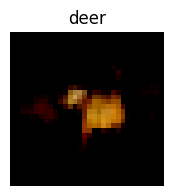

In [6]:
def show_image(img_tensor, label):
    # img_tensor: (3, 32, 32)
    img = img_tensor.permute(1, 2, 0)  # (H, W, C) for matplotlib
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.title(cnn_train_set.classes[label])
    plt.axis("off")
    plt.show()

show_image(x, y)

Display image without data normalization

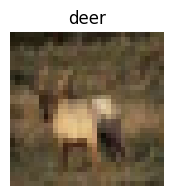

In [7]:
show_image(z, i)

Show a grid of multiple images--- with Data Normalization
CIFAR-10 is small images (32×32)---
Some classes look similar (cat vs dog), which is why it’s challenging

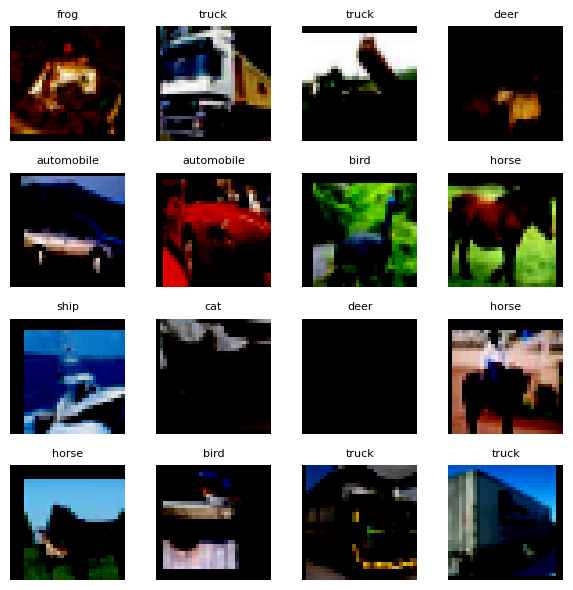

In [7]:
def show_batch(dataset, n=16):
    plt.figure(figsize=(6,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(cnn_train_set.classes[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(cnn_train_set, n=16)

Show images without data normalization

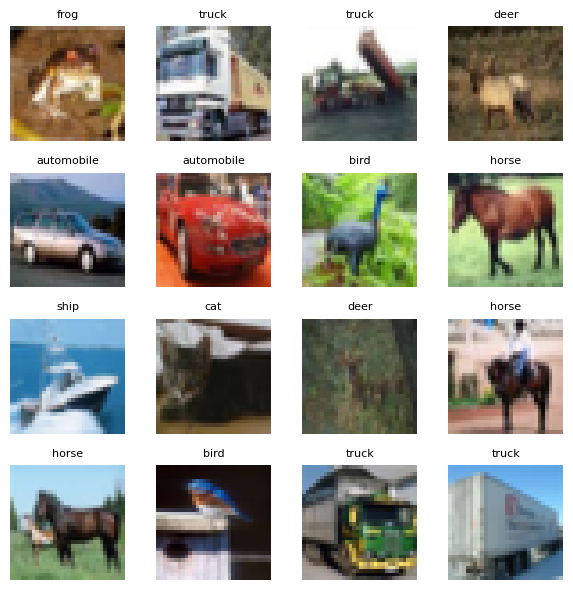

In [8]:
show_batch(train_set, n=16)

check class balance

In [9]:
from collections import Counter

labels = [train_set[i][1] for i in range(len(train_set))]
counts = Counter(labels)

for k in range(10):
    print(train_set.classes[k], ":", counts[k])

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


Flatten the image (turn 3×32×32 into 3072 numbers)

A fully connected network expects a 2D input: (batch, features)

CIFAR image (3,32,32) → 3*32*32 = 3072 features

Now you have (B, 3072)

In [10]:

xb, yb = next(iter(cnn_train_loader))  # xb: (B, 3, 32, 32)

print("Before flatten:", xb.shape)

xb_flat = xb.view(xb.shape[0], -1)  # (B, 3072)

print("After flatten:", xb_flat.shape)
print("One image becomes length:", xb_flat.shape[1])

Before flatten: torch.Size([128, 3, 32, 32])
After flatten: torch.Size([128, 3072])
One image becomes length: 3072


CNN with FCNN Layers Model Definition

In [11]:
import torch
import torch.nn.functional as F
import math


# ==================================================
# Manual zero padding
# ==================================================
def manual_pad(x, pad):
    if pad == 0:
        return x

    N, C, H, W = x.shape
    out = torch.zeros(
        (N, C, H + 2 * pad, W + 2 * pad),
        device=x.device,
        dtype=x.dtype
    )
    out[:, :, pad:pad + H, pad:pad + W] = x
    return out


# ==================================================
# Manual ReLU
# ==================================================
class ReLU:
    def forward(self, x):
        self.mask = (x > 0).to(x.dtype)
        return x * self.mask

    def backward(self, dout):
        # Ensure mask matches dout
        if self.mask.shape != dout.shape:
            raise ValueError(f"ReLU mask shape {self.mask.shape} does not match dout {dout.shape}")
        return dout * self.mask



# ==================================================
# Manual Linear Layer
# ==================================================
class Linear:
    def __init__(self, in_features, out_features, device="cpu"):
        scale = math.sqrt(2.0 / in_features)
        self.W = scale * torch.randn(in_features, out_features, device=device)
        self.b = torch.zeros(out_features, device=device)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        self.x = None

    def forward(self, x):
        self.x = x
        #print("x shape", x.shape)
        #print("forward W shape", self.W.shape)
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW.copy_(self.x.t() @ dout)
        self.db.copy_(dout.sum(dim=0))
        dx = dout @ self.W.t()
        return dx


# ==================================================
# Manual Conv2D Layer
# ==================================================
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, device="cpu"):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.device = device

        fan_in = in_channels * kernel_size * kernel_size

        scale = math.sqrt(2.0 / fan_in)

        self.W = scale * torch.randn(
            out_channels, in_channels, kernel_size, kernel_size, device=device
        )
        #print("W Shape", self.W.shape)
        self.b = torch.zeros(out_channels, device=device)

        #print("fb Shape:", self.b.shape)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        self.x = None
        self.x_padded = None
        self.x_cols = None

    def forward(self, x):
        self.x = x

        P = self.padding
        S = self.stride
        KH = self.kernel_size
        KW = self.kernel_size

        self.x_padded = manual_pad(x, P)
        self.x_cols = self.x_padded.unfold(2, KH, S).unfold(3, KW, S)

        out = torch.einsum('nchwkl,fckl->nfhw', self.x_cols, self.W)
        out = out + self.b[None, :, None, None]
        return out

    def backward(self, dout):
        _, _, KH, KW = self.W.shape
        P = self.padding
        S = self.stride
        H_out = dout.shape[2]
        W_out = dout.shape[3]

        self.db.copy_(dout.sum(dim=(0, 2, 3)))
        self.dW.copy_(torch.einsum('nchwkl,nfhw->fckl', self.x_cols, dout))

        dx_cols = torch.einsum('nfhw,fckl->nchwkl', dout, self.W)
        dx_padded = torch.zeros_like(self.x_padded)

        for kh in range(KH):
            for kw in range(KW):
                dx_padded[:, :, kh:kh + S * H_out:S, kw:kw + S * W_out:S] += dx_cols[:, :, :, :, kh, kw]

        if P > 0:
            dx = dx_padded[:, :, P:-P, P:-P]
        else:
            dx = dx_padded

        return dx


# ==================================================
# AvgPool2D
# Note: F.avg_pool2d is allowed by your project rules
# ==================================================
class AvgPool2D:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        k = self.kernel_size
        s = self.stride

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        out = torch.zeros((N, C, H_out, W_out), device=x.device)

        for i in range(H_out):
            for j in range(W_out):
                out[:, :, i, j] = x[:, :, i*s:i*s+k, j*s:j*s+k].mean(dim=(2, 3))

        return out

    def backward(self, dout):
        N, C, H, W = self.x.shape
        k = self.kernel_size
        s = self.stride

        dx = torch.zeros_like(self.x)

        H_out = dout.shape[2]
        W_out = dout.shape[3]

        for i in range(H_out):
            for j in range(W_out):
                dx[:, :, i*s:i*s+k, j*s:j*s+k] += dout[:, :, i, j].unsqueeze(-1).unsqueeze(-1) / (k*k)

        return dx
# ==================================================
# MaxPool2D
# Note: F.avg_pool2d is allowed by your project rules
# ==================================================
class MaxPool2D:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        k = self.kernel_size
        s = self.stride

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        out = torch.zeros((N, C, H_out, W_out), device=x.device)
        self.max_mask = torch.zeros_like(x)

        for i in range(H_out):
            for j in range(W_out):
                window = x[:, :, i*s:i*s+k, j*s:j*s+k]
                max_vals, max_idx = window.reshape(N, C, -1).max(dim=2)

                out[:, :, i, j] = max_vals

                # Create mask
                mask = torch.zeros_like(window).reshape(N, C, -1)
                mask.scatter_(2, max_idx.unsqueeze(2), 1)
                mask = mask.reshape_as(window)

                self.max_mask[:, :, i*s:i*s+k, j*s:j*s+k] += mask

        return out

    def backward(self, dout):
        k = self.kernel_size
        s = self.stride

        dx = torch.zeros_like(self.x)
        N, C, H_out, W_out = dout.shape

        for i in range(H_out):
            for j in range(W_out):
                dx[:, :, i*s:i*s+k, j*s:j*s+k] += (
                    self.max_mask[:, :, i*s:i*s+k, j*s:j*s+k] *
                    dout[:, :, i, j].unsqueeze(-1).unsqueeze(-1)
                )

        return dx

# ==================================================
# Momentum definition
# ==================================================

class SGDMomentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = params
        self.lr = lr
        self.momentum = momentum

        # Initialize velocities
        self.velocities = [torch.zeros_like(p) for p, _ in self.params]

    def step(self):
        for i, (p, dp) in enumerate(self.params):

            # v = μ * v - lr * grad
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * dp

            # param = param + v
            p += self.velocities[i]

            # Reset gradient immediately
            dp.zero_()

# --------------------------------------------------
# Manual Adam Optimizer
#
# Adam combines:
#   - Momentum (first moment)
#   - RMSProp (second moment)
#
# Update rule:
#   m = β1 * m + (1 - β1) * grad
#   v = β2 * v + (1 - β2) * grad^2
#
#   m_hat = m / (1 - β1^t)
#   v_hat = v / (1 - β2^t)
#
#   param = param - lr * m_hat / (sqrt(v_hat) + eps)
# --------------------------------------------------

class AdamManual:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        """
        Initialize Adam optimizer.

        params : list of (parameter, gradient) tuples
        lr     : learning rate (η)
        beta1  : decay rate for first moment (momentum)
        beta2  : decay rate for second moment (variance)
        eps    : small value to avoid division by zero
        """

        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # time step
        self.t = 0

        # first moment (mean of gradients)
        self.m = []

        # second moment (variance of gradients)
        self.v = []

        # initialize m and v for each parameter
        for p, dp in self.params:
            self.m.append(torch.zeros_like(p))
            self.v.append(torch.zeros_like(p))

    def step(self):
        """
        Perform one optimization step using Adam.
        """

        # increment time step
        self.t += 1

        for i, (p, dp) in enumerate(self.params):

            # -------------------------------
            # Update biased first moment
            # -------------------------------
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * dp

            # -------------------------------
            # Update biased second moment
            # -------------------------------
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (dp ** 2)

            # -------------------------------
            # Bias correction
            # -------------------------------
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # -------------------------------
            # Parameter update
            # -------------------------------
            p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

        # -------------------------------
        # Reset gradients after update
        # -------------------------------
        for p, dp in self.params:
            dp.zero_()


import math

# --------------------------------------------------
# Cosine Annealing Learning Rate Scheduler
#
# Gradually decreases learning rate using a cosine curve.
#
# Formula:
#   lr = initial_lr * 0.5 * (1 + cos(pi * epoch / total_epochs))
#
# Behavior:
#   - Starts high
#   - Smoothly decays toward 0
#   - No sudden jumps
# --------------------------------------------------
def cosine_lr(initial_lr, epoch, total_epochs):
    return initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))


# --------------------------------------------------
# Step Decay Learning Rate Scheduler
#
# Reduces learning rate at fixed intervals.
#
# Formula:
#   lr = initial_lr * (drop ^ floor(epoch / every))
#
# Parameters:
#   drop  : factor to reduce LR (e.g., 0.5 halves it)
#   every : number of epochs before reducing LR
#
# Example:
#   every = 10:
#     epoch 0–9   → lr
#     epoch 10–19 → lr * drop
#     epoch 20–29 → lr * drop^2
# --------------------------------------------------
def step_decay_lr(initial_lr, epoch, drop=0.5, every=10):
    return initial_lr * (drop ** (epoch // every))


# ==================================================
# Softmax + Cross Entropy
# ==================================================
def softmax(logits):
    z = logits - logits.max(dim=1, keepdim=True).values
    exp = torch.exp(z)
    return exp / exp.sum(dim=1, keepdim=True)


def cross_entropy_loss_from_logits(logits, y):
    N = logits.shape[0]
    probs = softmax(logits)

    eps = 1e-12
    correct_probs = probs[torch.arange(N, device=logits.device), y]
    loss = (-torch.log(correct_probs + eps)).mean()

    dlogits = probs.clone()
    dlogits[torch.arange(N, device=logits.device), y] -= 1.0
    dlogits /= N

    return loss, dlogits


# ==================================================
# Accuracy
# ==================================================
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


# ==================================================
# Manual CNN
# ==================================================
class ManualCNN:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device

        # self.conv1 = Conv2D(3, 16, kernel_size=3, stride=1, padding=1, device=device)
        # self.relu1 = ReLU()
        # self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        # self.conv2 = Conv2D(16, 32, kernel_size=3, stride=1, padding=1, device=device)
        # self.relu2 = ReLU()
        # self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        # self.fc1 = Linear(32 * 8 * 8, 128, device=device)
        # self.relu3 = ReLU()
        # self.fc2 = Linear(128, num_classes, device=device)

        self.conv1 = Conv2D(3, 32, kernel_size=3, stride=1, padding=1, device=device)
        self.relu1 = ReLU()
        self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        self.conv2 = Conv2D(32, 64, kernel_size=3, stride=1, padding=1, device=device)
        self.relu2 = ReLU()
        self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        self.fc1 = Linear(64 * 8 * 8, 256, device=device)
        self.relu3 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        x = self.conv1.forward(x)
        #print("conv1",x.shape)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        x = self.fc1.forward(x)
        x = self.relu3.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu3.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        self.conv1.dW.zero_()
        self.conv1.db.zero_()
        self.conv2.dW.zero_()
        self.conv2.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW),
            (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW),
            (self.conv2.b, self.conv2.db),
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]

In [15]:
# --------------------------------------------------
# Evaluate Manual CNN
#
# No gradients needed during evaluation
# Returns accuracy as a fraction (example: 0.1032)
# --------------------------------------------------

@torch.no_grad()
def evaluate_cnn(model, loader, device="cpu"):
    correct = 0
    total = 0

    # Turn off dropout during evaluation if it exists
    if hasattr(model, "dropout"):
        model.dropout.training = False

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model.forward(xb)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

    # Accuracy as fraction, not percent
    acc = correct / total

    # Turn dropout back on for training
    if hasattr(model, "dropout"):
        model.dropout.training = True

    return acc

**CNN training loop with manual optimizer and LR decay**

In [12]:

def train_cnn_manual(model, train_loader, test_loader,
                     optimizer_type="momentum",
                     scheduler_type=None,
                     epochs=5,
                     initial_lr=0.001,
                     device="cpu"):

    # Store history for plotting later
    train_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    lr_hist = []

    # --------------------------------------------------
    # Initialize optimizer (manual implementation)
    # --------------------------------------------------
    if optimizer_type == "momentum":
        optimizer = SGDMomentum(model.params(), lr=initial_lr, momentum=0.9)
    elif optimizer_type == "adam":
        optimizer = AdamManual(model.params(), lr=initial_lr)
    else:
        raise ValueError("optimizer_type must be 'momentum' or 'adam'")

    # --------------------------------------------------
    # Training loop over epochs
    # --------------------------------------------------
    for epoch in range(1, epochs + 1):

        running_loss = 0.0   # sum of batch losses
        correct = 0          # number of correct predictions
        total = 0            # total samples

        # --------------------------------------------------
        # Learning rate scheduler (manual)
        # --------------------------------------------------
        if scheduler_type == "cosine":
            current_lr = cosine_lr(initial_lr, epoch - 1, epochs)
        elif scheduler_type == "step":
            current_lr = step_decay_lr(initial_lr, epoch - 1, drop=0.5, every=10)
        else:
            current_lr = initial_lr  # constant LR

        optimizer.lr = current_lr
        lr_hist.append(current_lr)

        # --------------------------------------------------
        # If model has dropout, enable training mode
        # --------------------------------------------------
        if hasattr(model, "dropout"):
            model.dropout.training = True

        # --------------------------------------------------
        # Loop over mini-batches
        # --------------------------------------------------
        for xb, yb in train_loader:

            # Move data to CPU/GPU
            xb = xb.to(device)
            yb = yb.to(device)

            # -----------------------
            # Forward pass
            # -----------------------
            logits = model.forward(xb)

            # -----------------------
            # Compute loss + gradient
            # -----------------------
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # -----------------------
            # Backward pass
            # -----------------------
            model.backward(dlogits)

            # -----------------------
            # Update parameters
            # -----------------------
            optimizer.step()

            # -----------------------
            # Logging metrics
            # -----------------------
            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1)   # predicted class
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # --------------------------------------------------
        # Compute epoch-level metrics
        # --------------------------------------------------
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Evaluate on test dataset
        test_acc = evaluate_cnn(model, test_loader, device=device)

        # Save history
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_acc_hist.append(test_acc)

        # --------------------------------------------------
        # Print progress
        # --------------------------------------------------
        print(
            f"Epoch {epoch}: "
            f"lr={current_lr:.6f} "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc*100:.2f}% "
            f"test_acc={test_acc*100:.2f}%"
        )

    # Return all logs for analysis/plots
    return train_loss_hist, train_acc_hist, test_acc_hist, lr_hist

**Revised CNN-FCNN Model with 2 Convolution layers** (different kernel sizes and strides)

In [13]:
class ManualCNN_2layers_kern:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device
        ### Input (32, 32, 3)
        ### Ouput of Conv 1 with kernel_size = 5 and stride = 1 and padding = 0
        ### Conv1 Output (28, 28, 6)
        ### Output after pool1 (14, 14, 6)
        self.conv1 = Conv2D(3, 6, kernel_size=5, stride=1, padding=0, device=device)
        self.relu1 = ReLU()
        self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        ### Output after conv2
        ### Conv2 output (10,10,16)
        ### Output after pool2 (5,5,3)


        self.conv2 = Conv2D(6, 16, kernel_size=5, stride=1, padding=0, device=device)
        self.relu2 = ReLU()
        self.pool2 = AvgPool2D(kernel_size=2, stride=2)


        self.fc1 = Linear(16*5*5, 256, device=device)
        self.relu3 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        x = self.conv1.forward(x)
        #print("conv1",x.shape)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        x = self.fc1.forward(x)
        x = self.relu3.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu3.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        self.conv1.dW.zero_()
        self.conv1.db.zero_()
        self.conv2.dW.zero_()
        self.conv2.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW),
            (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW),
            (self.conv2.b, self.conv2.db),
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]

**Revised CNN -FCNN Model with 3 convolution layers**

In [ ]:
# ==================================================
# Manual CNN_ optimization with 3 Convolution layers
# ==================================================
class ManualCNN_opt:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device

        # -------------------------
        # Block 1
        # -------------------------
        self.conv1 = Conv2D(3, 32, kernel_size=3, stride=1, padding=1, device=device)
        self.relu1 = ReLU()
        self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Block 2
        # -------------------------
        self.conv2 = Conv2D(32, 64, kernel_size=5, stride=1, padding=1, device=device)
        self.relu2 = ReLU()
        self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Block 3 (NEW)
        # -------------------------
        self.conv3 = Conv2D(64, 128, kernel_size=3, stride=1, padding=1, device=device)
        self.relu3 = ReLU()
        self.pool3 = AvgPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Fully Connected
        # -------------------------
        # After Conv3+Pool3, final shape = 32 × 1 × 1  (see shape math below)
        self.fc1 = Linear(128 * 3 * 3, 256, device=device)
        self.relu4 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        # Block 1
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        # Block 2
        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        # Block 3
        x = self.conv3.forward(x)
        x = self.relu3.forward(x)
        x = self.pool3.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        # FC
        x = self.fc1.forward(x)
        x = self.relu4.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu4.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        # Block 3
        dx = self.pool3.backward(dx)
        dx = self.relu3.backward(dx)
        dx = self.conv3.backward(dx)

        # Block 2
        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        # Block 1
        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        for layer in [self.conv1, self.conv2, self.conv3]:
            layer.dW.zero_()
            layer.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW), (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW), (self.conv2.b, self.conv2.db),
            (self.conv3.W, self.conv3.dW), (self.conv3.b, self.conv3.db),
            (self.fc1.W, self.fc1.dW),     (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),     (self.fc2.b, self.fc2.db),
        ]


**Revised CNN -FCNN Model with 3 convolution layers and max pooling layers**

In [ ]:
# ==================================================
# Manual CNN_ optimization with 3 Convolution layers and maxpool function
# ==================================================


class ManualCNN_opt_maxpool:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device

        # -------------------------
        # Block 1
        # -------------------------
        self.conv1 = Conv2D(3, 32, kernel_size=3, stride=1, padding=1, device=device)
        self.relu1 = ReLU()
        #self.pool1 = AvgPool2D(kernel_size=2, stride=2)
        self.pool1 = MaxPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Block 2
        # -------------------------
        self.conv2 = Conv2D(32, 64, kernel_size=5, stride=1, padding=1, device=device)
        self.relu2 = ReLU()
        #self.pool2 = AvgPool2D(kernel_size=2, stride=2)
        self.pool2 = MaxPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Block 3 (NEW)
        # -------------------------
        self.conv3 = Conv2D(64, 128, kernel_size=3, stride=1, padding=1, device=device)
        self.relu3 = ReLU()
        #self.pool3 = AvgPool2D(kernel_size=2, stride=2)
        self.pool3 = MaxPool2D(kernel_size=2, stride=2)

        # -------------------------
        # Fully Connected
        # -------------------------
        # After Conv3+Pool3, final shape = 32 × 1 × 1  (see shape math below)
        self.fc1 = Linear(128 * 3 * 3, 256, device=device)
        self.relu4 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        # Block 1
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        # Block 2
        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        # Block 3
        x = self.conv3.forward(x)
        x = self.relu3.forward(x)
        x = self.pool3.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        # FC
        x = self.fc1.forward(x)
        x = self.relu4.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu4.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        # Block 3
        dx = self.pool3.backward(dx)
        dx = self.relu3.backward(dx)
        dx = self.conv3.backward(dx)

        # Block 2
        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        # Block 1
        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        for layer in [self.conv1, self.conv2, self.conv3]:
            layer.dW.zero_()
            layer.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW), (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW), (self.conv2.b, self.conv2.db),
            (self.conv3.W, self.conv3.dW), (self.conv3.b, self.conv3.db),
            (self.fc1.W, self.fc1.dW),     (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),     (self.fc2.b, self.fc2.db),
        ]


**Experiment 1: CNN model (2 layers with different Kernel size) + Adam + Step**

In [16]:

cnn_adam_2lKern = ManualCNN_2layers_kern(num_classes=10, device=device)

loss_adam_2lk, train_acc_adam_2lk, test_acc_adam_2lk, lr_2lk = train_cnn_manual(
    cnn_adam_2lKern,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=20,
    initial_lr=0.01,
    device=device
)

Epoch 1: lr=0.010000 train_loss=1.8425 train_acc=31.25% test_acc=40.72%
Epoch 2: lr=0.010000 train_loss=1.6717 train_acc=38.59% test_acc=44.46%
Epoch 3: lr=0.010000 train_loss=1.6035 train_acc=41.10% test_acc=46.50%
Epoch 4: lr=0.010000 train_loss=1.5610 train_acc=43.35% test_acc=47.40%
Epoch 5: lr=0.010000 train_loss=1.5227 train_acc=44.92% test_acc=49.23%
Epoch 6: lr=0.010000 train_loss=1.4985 train_acc=45.84% test_acc=48.59%
Epoch 7: lr=0.010000 train_loss=1.4669 train_acc=47.21% test_acc=51.70%
Epoch 8: lr=0.010000 train_loss=1.4287 train_acc=49.04% test_acc=52.58%
Epoch 9: lr=0.010000 train_loss=1.4168 train_acc=49.54% test_acc=52.48%
Epoch 10: lr=0.010000 train_loss=1.3951 train_acc=50.22% test_acc=54.25%
Epoch 11: lr=0.005000 train_loss=1.3121 train_acc=53.09% test_acc=56.15%
Epoch 12: lr=0.005000 train_loss=1.2911 train_acc=54.13% test_acc=55.43%
Epoch 13: lr=0.005000 train_loss=1.2801 train_acc=54.54% test_acc=57.17%
Epoch 14: lr=0.005000 train_loss=1.2643 train_acc=55.15% tes

**Experiment 2: CNN Model + momemtum + optimization with 3 Conv layers**

In [ ]:
cnn_momentum_opt = ManualCNN_opt(num_classes=10, device=device)

loss_momentum_opt, train_acc_momentum_opt, test_acc_momentum_opt, lr_momentum_opt = train_cnn_manual(
    cnn_momentum_opt,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="momentum",
    scheduler_type="cosine",
    epochs=25,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=2.0075 train_acc=26.98% test_acc=36.14%
Epoch 2: lr=0.000996 train_loss=1.7818 train_acc=36.31% test_acc=41.98%
Epoch 3: lr=0.000984 train_loss=1.6584 train_acc=40.38% test_acc=45.88%
Epoch 4: lr=0.000965 train_loss=1.5823 train_acc=42.96% test_acc=47.75%
Epoch 5: lr=0.000938 train_loss=1.5290 train_acc=44.93% test_acc=49.49%
Epoch 6: lr=0.000905 train_loss=1.4863 train_acc=46.53% test_acc=51.24%
Epoch 7: lr=0.000864 train_loss=1.4502 train_acc=47.70% test_acc=52.30%
Epoch 8: lr=0.000819 train_loss=1.4356 train_acc=48.79% test_acc=52.32%
Epoch 9: lr=0.000768 train_loss=1.4018 train_acc=49.83% test_acc=54.20%
Epoch 10: lr=0.000713 train_loss=1.3813 train_acc=50.80% test_acc=53.99%
Epoch 11: lr=0.000655 train_loss=1.3605 train_acc=51.42% test_acc=55.07%
Epoch 12: lr=0.000594 train_loss=1.3470 train_acc=52.18% test_acc=56.45%
Epoch 13: lr=0.000531 train_loss=1.3290 train_acc=52.87% test_acc=56.64%
Epoch 14: lr=0.000469 train_loss=1.3125 train_acc=53.35% tes

**Experiment 3: CNN Model + momemtum (0.005) + optimization with 3 Conv layers**

In [ ]:
cnn_momentum_opt_adam = ManualCNN_opt(num_classes=10, device=device)

loss_momentum_opt_adam, train_acc_momentum_opt_adam, test_acc_momentum_opt_adam, lr_momentum_opt_adam = train_cnn_manual(
    cnn_momentum_opt_adam,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type=None,
    epochs=20,
    initial_lr=0.005,
    device=device
)

Epoch 1: lr=0.005000 train_loss=1.6686 train_acc=39.06% test_acc=49.35%
Epoch 2: lr=0.005000 train_loss=1.3810 train_acc=50.18% test_acc=56.13%
Epoch 3: lr=0.005000 train_loss=1.2518 train_acc=54.86% test_acc=59.93%
Epoch 4: lr=0.005000 train_loss=1.1562 train_acc=58.60% test_acc=64.82%
Epoch 5: lr=0.005000 train_loss=1.0917 train_acc=61.50% test_acc=64.61%
Epoch 6: lr=0.005000 train_loss=1.0317 train_acc=63.70% test_acc=66.09%
Epoch 7: lr=0.005000 train_loss=0.9924 train_acc=64.89% test_acc=67.41%
Epoch 8: lr=0.005000 train_loss=0.9683 train_acc=65.96% test_acc=68.44%
Epoch 9: lr=0.005000 train_loss=0.9424 train_acc=66.79% test_acc=68.97%
Epoch 10: lr=0.005000 train_loss=0.9154 train_acc=67.95% test_acc=69.87%
Epoch 11: lr=0.005000 train_loss=0.9018 train_acc=68.36% test_acc=69.05%
Epoch 12: lr=0.005000 train_loss=0.8914 train_acc=68.86% test_acc=70.88%
Epoch 13: lr=0.005000 train_loss=0.8697 train_acc=69.55% test_acc=71.68%
Epoch 14: lr=0.005000 train_loss=0.8503 train_acc=70.41% tes

**Experiment 4: CNN Model + Adam + Step (0.001) + optimization with 3 Conv layers**

In [ ]:
cnn_momentum_opt_adam_1 = ManualCNN_opt(num_classes=10, device=device)

loss_momentum_opt_adam_1, train_acc_momentum_opt_adam_1, test_acc_momentum_opt_adam_1, lr_momentum_opt_adam_1 = train_cnn_manual(
    cnn_momentum_opt_adam_1,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=25,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.6114 train_acc=40.98% test_acc=53.24%
Epoch 2: lr=0.001000 train_loss=1.2988 train_acc=53.48% test_acc=58.22%
Epoch 3: lr=0.001000 train_loss=1.1414 train_acc=59.43% test_acc=64.39%
Epoch 4: lr=0.001000 train_loss=1.0237 train_acc=63.63% test_acc=67.79%
Epoch 5: lr=0.001000 train_loss=0.9468 train_acc=66.56% test_acc=70.37%
Epoch 6: lr=0.001000 train_loss=0.8830 train_acc=68.91% test_acc=70.29%
Epoch 7: lr=0.001000 train_loss=0.8336 train_acc=70.78% test_acc=72.71%
Epoch 8: lr=0.001000 train_loss=0.7856 train_acc=72.22% test_acc=73.87%
Epoch 9: lr=0.001000 train_loss=0.7461 train_acc=73.81% test_acc=74.68%
Epoch 10: lr=0.001000 train_loss=0.7171 train_acc=74.85% test_acc=75.59%
Epoch 11: lr=0.000500 train_loss=0.6464 train_acc=77.18% test_acc=77.20%
Epoch 12: lr=0.000500 train_loss=0.6228 train_acc=78.20% test_acc=77.20%
Epoch 13: lr=0.000500 train_loss=0.6051 train_acc=78.72% test_acc=77.59%
Epoch 14: lr=0.000500 train_loss=0.5896 train_acc=79.30% tes

**Experiment 5: CNN Model + Adam + Step (0.001) + optimization with 3 Conv layers** (max pooling)

In [ ]:
cnn_momentum_opt_adam_maxpool = ManualCNN_opt_maxpool(num_classes=10, device=device)

loss_momentum_opt_adam_maxpool, train_acc_momentum_opt_adam_maxpool, test_acc_momentum_opt_adam_maxpool, lr_momentum_opt_adam_maxpool = train_cnn_manual(
    cnn_momentum_opt_adam_maxpool,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=25,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.6543 train_acc=40.09% test_acc=53.58%
Epoch 2: lr=0.001000 train_loss=1.2776 train_acc=54.34% test_acc=60.57%
Epoch 3: lr=0.001000 train_loss=1.1085 train_acc=60.81% test_acc=64.52%
Epoch 4: lr=0.001000 train_loss=0.9955 train_acc=64.77% test_acc=65.84%
Epoch 5: lr=0.001000 train_loss=0.9230 train_acc=67.43% test_acc=70.22%
Epoch 6: lr=0.001000 train_loss=0.8658 train_acc=69.55% test_acc=70.87%
Epoch 7: lr=0.001000 train_loss=0.8169 train_acc=71.24% test_acc=72.78%
Epoch 8: lr=0.001000 train_loss=0.7733 train_acc=72.74% test_acc=74.09%
Epoch 9: lr=0.001000 train_loss=0.7422 train_acc=74.06% test_acc=74.42%
Epoch 10: lr=0.001000 train_loss=0.7095 train_acc=74.90% test_acc=75.54%
Epoch 11: lr=0.000500 train_loss=0.6417 train_acc=77.54% test_acc=77.38%
Epoch 12: lr=0.000500 train_loss=0.6195 train_acc=78.21% test_acc=77.65%
Epoch 13: lr=0.000500 train_loss=0.6058 train_acc=78.73% test_acc=77.52%
Epoch 14: lr=0.000500 train_loss=0.5899 train_acc=79.52% tes